In [2]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ------- -------------------------------- 1.8/9.5 MB 10.0 MB/s eta 0:00:01
   --------------- ------------------------ 3.7/9.5 MB 9.4 MB/s eta 0:00:01
   -------------------- ------------------- 5.0/9.5 MB 8.5 MB/s eta 0:00:01
   -------------------------- ------------- 6.3/9.5 MB 7.7 MB/s eta 0:00:01
   -------------------------------- ------- 7.9/9.5 MB 7.8 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 7.8 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 7.4 MB/s  0:00:01

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/

Zonas cargadas: 332
Temperatura cargada: 7636 registros
Árboles cargados: 234824

Columnas en arboles_en_zonas: ['geometry', 'index_right', 'OBJECTID', 'NOMBRE', 'ABREVIATURA', 'SUBTIPO_BARRIOVEREDA', 'SHAPE_Length', 'SHAPE_Area', 'Tipo']
Usando columna 'index_right' para agrupar
Conteo completado: 313 zonas con árboles
Zonas urbanas seleccionadas: 271 barrios
Árboles totales en zona urbana: 197536
Densidad media de árboles: 1803.78 árboles/km²

MODELO GAUSSIANO (REGRESIÓN LINEAL) - ZONAS URBANAS
                            OLS Regression Results                            
Dep. Variable:             Temp_media   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.5733
Date:                Fri, 17 Jul 2026   Prob (F-statistic):              0.564
Time:                        03:08:35   Log-Likelihood:                -707.10
No. Observations:       

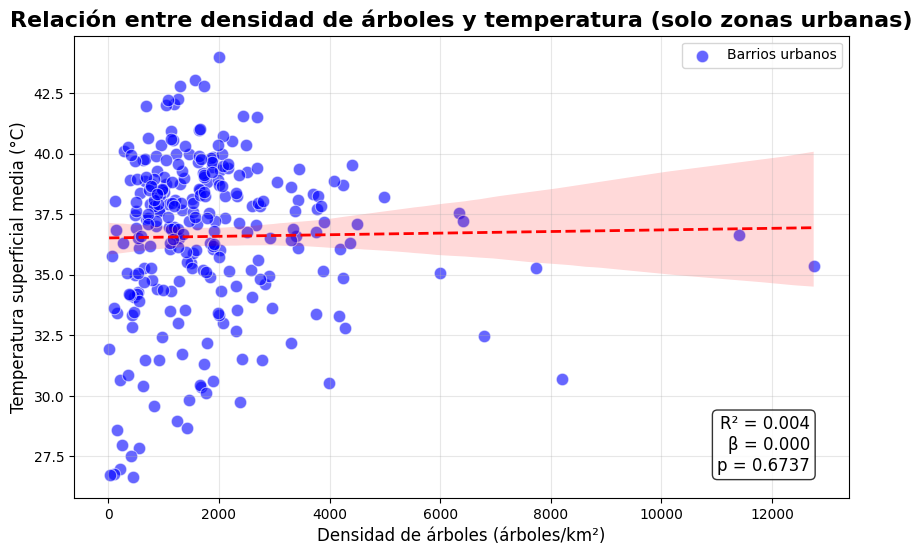

Gráfico guardado en: C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Resultados\Modelo_Gaussiano_Urbano.png


In [3]:
import pandas as pd
import geopandas as gpd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# Cargar zonas
ruta_zonas = r"C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Datos/Datos_procesados/Zonas_Medellin.gpkg"
zonas = gpd.read_file(ruta_zonas)

# Cargar temperatura
ruta_temp = r"C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Datos/Datos_procesados/Temperatura_por_zona.csv"
df_temp = pd.read_csv(ruta_temp)

print(f"Zonas cargadas: {len(zonas)}")
print(f"Temperatura cargada: {len(df_temp)} registros")

# arboles por barrio
# Cargar árboles 
ruta_arboles = r"C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Datos/Datos_procesados/Arboles_Activos_Medellin_TODOS.gpkg"

try:
    # Intentar cargar solo las columnas necesarias
    arboles = gpd.read_file(ruta_arboles, columns=['geometry'])
    print(f"Árboles cargados: {len(arboles)}")
except MemoryError:
    print("El archivo es muy grande. Usando una muestra aleatoria de 50,000 árboles...")
    arboles = gpd.read_file(ruta_arboles, rows=50000)
    print(f"Muestra de árboles cargada: {len(arboles)}")

# Verificar CRS
if arboles.crs != zonas.crs:
    arboles = arboles.to_crs(zonas.crs)

# unión espacial
arboles_en_zonas = gpd.sjoin(arboles, zonas, how='inner', predicate='within')

# Verificar qué columnas hay después del sjoin
print(f"\nColumnas en arboles_en_zonas: {arboles_en_zonas.columns.tolist()}")

# Si 'ID' no existe, usamos 'index_right' que es el índice de la tabla 'zonas'
if 'ID' in arboles_en_zonas.columns:
    columna_zona = 'ID'
else:
    # Si no hay 'ID', usamos 'index_right' (el índice de zonas)
    columna_zona = 'index_right'

print(f"Usando columna '{columna_zona}' para agrupar")

# Contar árboles por zona usando la columna correcta
conteo_arboles = arboles_en_zonas.groupby(columna_zona).size().reset_index(name='num_arboles')

# Renombrar la columna para que se llame 'ID' (para consistencia)
conteo_arboles = conteo_arboles.rename(columns={columna_zona: 'ID'})

print(f"Conteo completado: {len(conteo_arboles)} zonas con árboles")

# dataframe solo urabno

# Calcular temperatura promedio por zona (ID)
temp_promedio = df_temp.groupby('ID').agg({
    'Temp_media': 'mean',
    'Temp_max': 'mean',
    'Temp_min': 'mean'
}).reset_index()

# Unir temperatura con zonas (usando el índice de zonas)
zonas_temp = zonas.merge(temp_promedio, left_index=True, right_on='ID', how='left')

# Unir conteo de árboles
zonas_temp = zonas_temp.merge(conteo_arboles, on='ID', how='left')
zonas_temp['num_arboles'] = zonas_temp['num_arboles'].fillna(0).astype(int)

# Calcular área y densidad
zonas_temp['area_km2'] = zonas_temp.geometry.area / 1_000_000
zonas_temp['densidad_arboles'] = zonas_temp['num_arboles'] / zonas_temp['area_km2']

# --- FILTRAR SOLO ZONAS URBANAS ---
zonas_urbano = zonas_temp[zonas_temp['Tipo'] == 'Urbano'].copy()

print(f"Zonas urbanas seleccionadas: {len(zonas_urbano)} barrios")
print(f"Árboles totales en zona urbana: {zonas_urbano['num_arboles'].sum()}")
print(f"Densidad media de árboles: {zonas_urbano['densidad_arboles'].mean():.2f} árboles/km²")

# modelo

# --- Definir variables ---
y = zonas_urbano['Temp_media']
X = zonas_urbano[['densidad_arboles', 'area_km2']]

# Añadir constante
X = sm.add_constant(X)

# Ajustar modelo OLS
modelo = sm.OLS(y, X).fit()

# --- Mostrar resultados ---
print("\n" + "=" * 60)
print("MODELO GAUSSIANO (REGRESIÓN LINEAL) - ZONAS URBANAS")
print("=" * 60)
print(modelo.summary())

intercepto = modelo.params['const']
coef_densidad = modelo.params['densidad_arboles']
coef_area = modelo.params['area_km2']
r2 = modelo.rsquared
p_densidad = modelo.pvalues['densidad_arboles']

print(f"Ecuación del modelo:")
print(f"Temp_media = {intercepto:.2f} + ({coef_densidad:.4f}) * densidad_arboles + ({coef_area:.4f}) * area_km2")

print(f"Métricas del modelo:")
print(f"   R²: {r2:.4f}")
print(f"   R² ajustado: {modelo.rsquared_adj:.4f}")
print(f"   p-valor (F-test): {modelo.f_pvalue:.4f}")

print(f"Efecto de la densidad de árboles:")
print(f"   Coeficiente: {coef_densidad:.4f}")
print(f"   p-valor: {p_densidad:.4f}")

if p_densidad < 0.05:
    if coef_densidad < 0:
        print("El efecto es NEGATIVO y SIGNIFICATIVO: más árboles = menor temperatura.")
    else:
        print("El efecto es POSITIVO y SIGNIFICATIVO: más árboles = mayor temperatura.")
else:
    print("El efecto NO es estadísticamente significativo (p >= 0.05).")

# 

fig, ax = plt.subplots(1, figsize=(10, 6))

sns.scatterplot(data=zonas_urbano, x='densidad_arboles', y='Temp_media', 
                alpha=0.6, color='blue', s=80, label='Barrios urbanos')

sns.regplot(data=zonas_urbano, x='densidad_arboles', y='Temp_media', 
            scatter=False, color='red', line_kws={'linewidth':2, 'linestyle':'--'})

ax.set_title('Relación entre densidad de árboles y temperatura (solo zonas urbanas)', 
             fontsize=16, fontweight='bold')
ax.set_xlabel('Densidad de árboles (árboles/km²)', fontsize=12)
ax.set_ylabel('Temperatura superficial media (°C)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

ax.text(0.95, 0.05, f'R² = {r2:.3f}\nβ = {coef_densidad:.3f}\np = {p_densidad:.4f}', 
        transform=ax.transAxes,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8),
        fontsize=12, ha='right', va='bottom')

ruta_resultados = r"C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Resultados"
if not os.path.exists(ruta_resultados):
    os.makedirs(ruta_resultados)

ruta_grafico = os.path.join(ruta_resultados, "Modelo_Gaussiano_Urbano.png")
plt.savefig(ruta_grafico, dpi=300, bbox_inches='tight')
plt.show()

print(f"Gráfico guardado en: {ruta_grafico}")



Residuos calculados para 271 observaciones


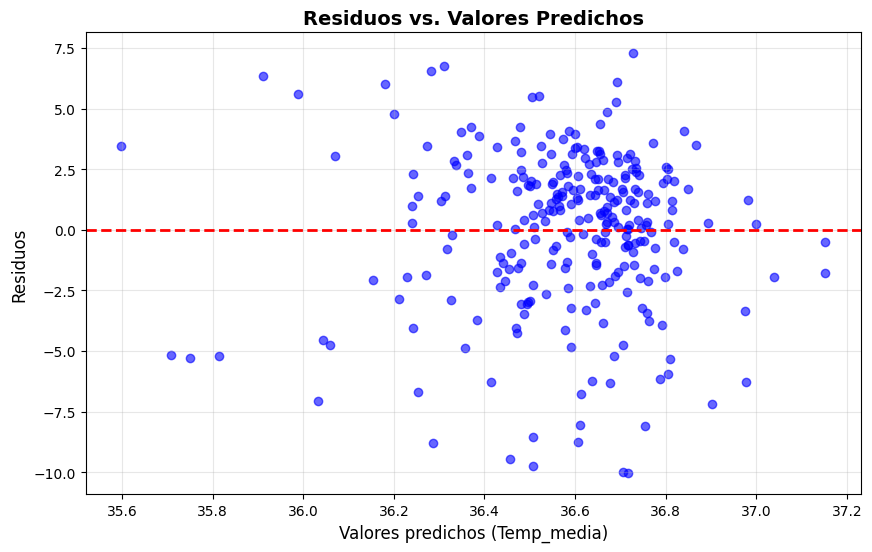

Gráfico 1 guardado: Residuos vs. Predichos


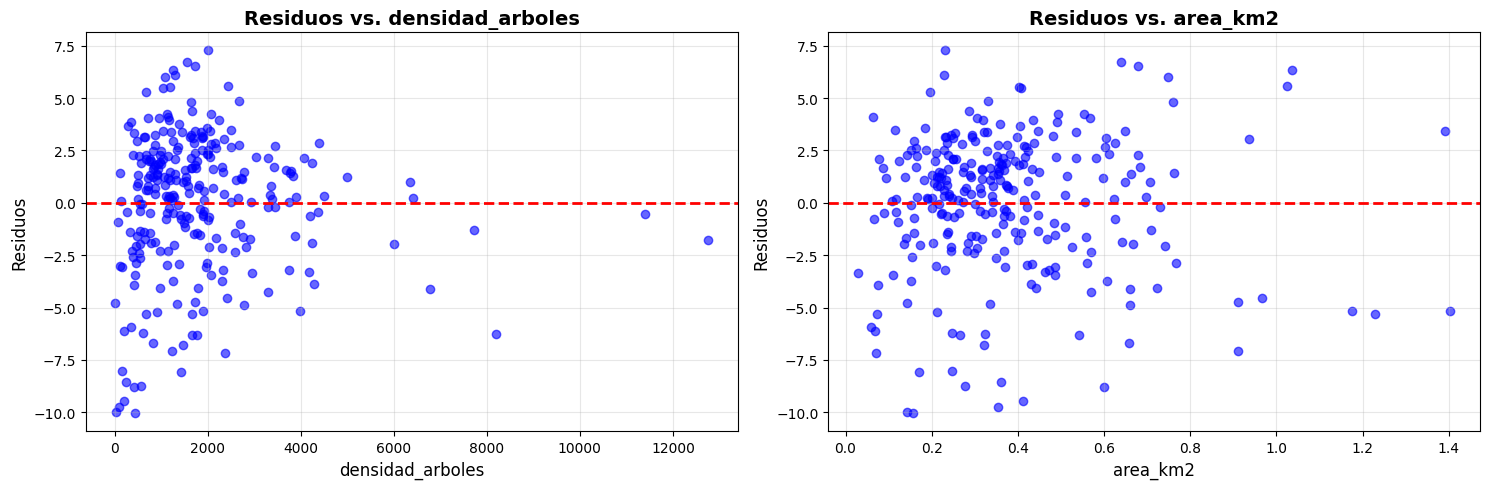

Gráfico 2 guardado: Residuos vs. Predictores
Prueba de Shapiro-Wilk para normalidad:
   Estadístico: 0.9588
   p-valor: 0.0000
 Los residuos NO siguen una distribución normal (se rechaza H0).
Estadísticas descriptivas de residuos:
   Media: 0.0000 (debe ser cercana a 0)
   Desviación estándar: 3.2941
   Mínimo: -10.0513
   Máximo: 7.2710


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np
import os

# Predecir valores usando el modelo
y_pred = modelo.predict(X)

# Calcular los residuos (diferencia entre valor observado y predicho)
residuals = y - y_pred

# Añadir los residuos al DataFrame para facilitar el análisis
zonas_urbano['residuales'] = residuals
zonas_urbano['y_pred'] = y_pred

print(f"Residuos calculados para {len(zonas_urbano)} observaciones")

# residuales vs predichos

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.6, color='blue')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Valores predichos (Temp_media)', fontsize=12)
plt.ylabel('Residuos', fontsize=12)
plt.title('Residuos vs. Valores Predichos', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Guardar
ruta_resultados = r"C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Resultados"
if not os.path.exists(ruta_resultados):
    os.makedirs(ruta_resultados)

plt.savefig(os.path.join(ruta_resultados, "Residuos_vs_Predichos.png"), dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico 1 guardado: Residuos vs. Predichos")

# =residuales vs variable predictora

# Lista de variables predictoras
variables = ['densidad_arboles', 'area_km2']

fig, axes = plt.subplots(1, len(variables), figsize=(15, 5))

for i, variable in enumerate(variables):
    ax = axes[i] if len(variables) > 1 else axes
    ax.scatter(zonas_urbano[variable], residuals, alpha=0.6, color='blue')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax.set_xlabel(variable, fontsize=12)
    ax.set_ylabel('Residuos', fontsize=12)
    ax.set_title(f'Residuos vs. {variable}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(ruta_resultados, "Residuos_vs_Predictores.png"), dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico 2 guardado: Residuos vs. Predictores")

# Prueba de normalidad (Shapiro-Wilk)
# Nota: Shapiro-Wilk es sensible a muestras grandes, se recomienda para n < 5000
if len(residuals) < 5000:
    shapiro_stat, shapiro_p = stats.shapiro(residuals)
    print(f"Prueba de Shapiro-Wilk para normalidad:")
    print(f"   Estadístico: {shapiro_stat:.4f}")
    print(f"   p-valor: {shapiro_p:.4f}")
    if shapiro_p > 0.05:
        print(" Los residuos siguen una distribución normal (no se rechaza H0).")
    else:
        print(" Los residuos NO siguen una distribución normal (se rechaza H0).")
else:
    print("Muestra grande (>5000). Usando prueba de Kolmogorov-Smirnov...")
    ks_stat, ks_p = stats.kstest(residuals, 'norm', args=(residuals.mean(), residuals.std()))
    print(f"   Estadístico: {ks_stat:.4f}")
    print(f"   p-valor: {ks_p:.4f}")
    if ks_p > 0.05:
        print(" Los residuos siguen una distribución normal (no se rechaza H0).")
    else:
        print(" Los residuos NO siguen una distribución normal (se rechaza H0).")

# Estadísticas descriptivas de los residuos
print(f"Estadísticas descriptivas de residuos:")
print(f"   Media: {residuals.mean():.4f} (debe ser cercana a 0)")
print(f"   Desviación estándar: {residuals.std():.4f}")
print(f"   Mínimo: {residuals.min():.4f}")
print(f"   Máximo: {residuals.max():.4f}")
